In [1]:
%%capture
!pip install "protobuf<5" vllm transformers langchain langgraph langchain_text_splitters -U -q

In [2]:
import numpy as np 
import pandas as pd 
import os
import ast
from tqdm import tqdm
from typing import List, Dict, Tuple, Any, TypedDict, Annotated
from vllm import LLM, SamplingParams
from langchain_core.runnables import RunnableLambda
from langchain_text_splitters import RecursiveCharacterTextSplitter
from transformers import AutoTokenizer
import torch
import psycopg2
from kaggle_secrets import UserSecretsClient
from IPython.display import display, Markdown, HTML

2026-04-20 09:20:58.884371: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776676859.289052      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776676859.407850      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776676860.406622      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776676860.406668      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776676860.406671      23 computation_placer.cc:177] computation placer alr

In [3]:
model_id = "Qwen/Qwen3-4B-Instruct-2507"
llm = LLM(
    model= model_id,
    tensor_parallel_size=2,  
    max_model_len=16384,     
    gpu_memory_utilization=0.85,
    attention_backend="TRITON_ATTN",
    dtype="float16" 
)
tokenizer = AutoTokenizer.from_pretrained(model_id)

INFO 04-20 09:21:39 [utils.py:261] non-default args: {'dtype': 'float16', 'max_model_len': 16384, 'tensor_parallel_size': 2, 'gpu_memory_utilization': 0.85, 'disable_log_stats': True, 'attention_backend': 'TRITON_ATTN', 'model': 'Qwen/Qwen3-4B-Instruct-2507'}


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

INFO 04-20 09:22:04 [model.py:541] Resolved architecture: Qwen3ForCausalLM
WARNING 04-20 09:22:04 [model.py:1885] Casting torch.bfloat16 to torch.float16.
INFO 04-20 09:22:04 [model.py:1561] Using max model len 16384
INFO 04-20 09:22:05 [scheduler.py:226] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-20 09:22:05 [vllm.py:624] Asynchronous scheduling is enabled.


generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

(Worker_TP1 pid=170) INFO 04-20 09:24:45 [backends.py:302] Cache the graph of compile range (1, 8192) for later use
(Worker_TP0 pid=169) INFO 04-20 09:24:50 [backends.py:302] Cache the graph of compile range (1, 8192) for later use
(Worker_TP0 pid=169) INFO 04-20 09:25:03 [backends.py:319] Compiling a graph for compile range (1, 8192) takes 26.02 s
(Worker_TP0 pid=169) INFO 04-20 09:25:03 [monitor.py:34] torch.compile takes 43.94 s in total
(EngineCore_DP0 pid=145) INFO 04-20 09:25:05 [shm_broadcast.py:542] No available shared memory broadcast block found in 60 seconds. This typically happens when some processes are hanging or doing some time-consuming work (e.g. compilation, weight/kv cache quantization).
(Worker_TP0 pid=169) INFO 04-20 09:25:06 [gpu_worker.py:356] Available KV cache memory: 7.05 GiB
(EngineCore_DP0 pid=145) INFO 04-20 09:25:06 [kv_cache_utils.py:1307] GPU KV cache size: 102,704 tokens
(EngineCore_DP0 pid=145) INFO 04-20 09:25:06 [kv_cache_utils.py:1312] Maximum concu

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:07<00:00,  7.21it/s]
Capturing CUDA graphs (decode, FULL):  97%|█████████▋| 34/35 [00:12<00:00,  3.09it/s]

(Worker_TP1 pid=170) INFO 04-20 09:25:26 [custom_all_reduce.py:216] Registering 6278 cuda graph addresses


Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:13<00:00,  2.55it/s]


(Worker_TP0 pid=169) INFO 04-20 09:25:27 [custom_all_reduce.py:216] Registering 6278 cuda graph addresses
(Worker_TP0 pid=169) INFO 04-20 09:25:28 [gpu_model_runner.py:5051] Graph capturing finished in 23 secs, took 0.52 GiB
(EngineCore_DP0 pid=145) INFO 04-20 09:25:28 [core.py:272] init engine (profile, create kv cache, warmup model) took 83.26 seconds
(EngineCore_DP0 pid=145) INFO 04-20 09:25:33 [vllm.py:624] Asynchronous scheduling is enabled.
INFO 04-20 09:25:33 [llm.py:343] Supported tasks: ['generate']


In [4]:
sampling_params = SamplingParams(temperature = 0, max_tokens=512)
messages = [{"role": "user", "content": "Кратко расскажи о больших языковых моделях."}]

prompt = tokenizer.apply_chat_template(
    messages, 
    tokenize=False, 
    add_generation_prompt=True
)

outputs = llm.generate([prompt], sampling_params)
for output in outputs:
    display(Markdown(f"Ответ: {output.outputs[0].text}\n"))

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Ответ: Большие языковые модели (БЯМ) — это искусственные интеллект-системы, обученные на огромных объёмах текстовых данных для понимания и генерации человеческих языковых конструкций. Они используют глубокие нейронные сети (обычно на основе трансформеров) и способны предсказывать следующие слова, строить связные тексты, отвечать на вопросы, суммировать информацию, писать письма, код и многое другое.

Ключевые особенности:

- **Обучение на больших объёмах текста** (миллиарды слов).
- **Понимание контекста** — учитывают последовательность слов.
- **Генерация текста** — могут создавать естественные, логичные фразы.
- **Масштабируемость** — модели, такие как GPT, Llama, BERT, могут быть адаптированы под разные задачи.

БЯМ широко применяются в чат-ботах, роботах-ассистентах, переводчиках, редактировании текстов, анализе данных и других областях. Однако они могут ошибаться, быть неэтичными или генерировать непроверенную информацию — поэтому важно использовать их с осторожностью и в сочетании с человеческим контролем.


In [5]:
secrets = UserSecretsClient()
db_params = {
    "dbname": "arxivdb",
    "user": secrets.get_secret("DB_USER"),
    "password": secrets.get_secret("DB_PASSWORD"),
    "host": secrets.get_secret("DB_HOST"),
    "port": "5433"  
}

with psycopg2.connect(**db_params) as conn:
    with conn.cursor() as cursor:
        cursor.execute("""SELECT id, title, abstract, clean_text, section_text_new, categories, pdf_url, authors 
                          FROM arxivdb.public.articles 
                          WHERE clean_text IS NOT NULL 
                          AND section_text_new IS NOT NULL
                          ORDER BY id
                          LIMIT 100""")
        rows = cursor.fetchall()
        



In [6]:
columns = ['id', 'title', 'abstract', 'full_text', 'sections', 'categories', 'pdf_url', 'authors']
df = pd.DataFrame(rows, columns=columns)
display(df.head())
df.info()

,id,title,abstract,full_text,sections,categories,pdf_url,authors
0,0704.0002,sparsity-certifying graph decompositions,"we describe a new algorithm, the $(k,\ell)$-pe...",Introduction and preliminaries The focus of th...,{'introduction and preliminaries': 'The focus ...,math.co cs.cg,https://export.arxiv.org/pdf/0704.0002.pdf,"""['ileana streinu', 'louis theran']"""
1,0704.0046,a limit relation for entropy and channel capac...,"in a quantum mechanical model, diosi, feldmann...","Introduction It was conjectured by Diósi, Feld...","{'Introduction': 'It was conjectured by Diósi,...",quant-ph cs.it math.it,https://export.arxiv.org/pdf/0704.0046.pdf,"""['i. csiszar', 'f. hiai', 'd. petz']"""
2,0704.0047,intelligent location of simultaneously active ...,the intelligent acoustic emission locator is d...,INTRODUCTION Acoustic emission (AE) concerns n...,{'introduction': 'Acoustic emission (AE) conce...,cs.ne cs.ai,https://export.arxiv.org/pdf/0704.0047.pdf,"""['t. kosel', 'i. grabec']"""
3,0704.0050,intelligent location of simultaneously active ...,part i describes an intelligent acoustic emiss...,INTRODUCTION A common goal of many non-destruc...,{'introduction': 'A common goal of many non-de...,cs.ne cs.ai,https://export.arxiv.org/pdf/0704.0050.pdf,"""['t. kosel', 'i. grabec']"""
4,0704.0062,on-line viterbi algorithm and its relationship...,"in this paper, we introduce the on-line viterb...",Introduction Hidden Markov models (HMMs) are g...,{'introduction': 'Hidden Markov models (HMMs) ...,cs.ds,https://export.arxiv.org/pdf/0704.0062.pdf,"""['rastislav \u0161r\u00e1mek', 'bro\u0148a br..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          100 non-null    object
 1   title       100 non-null    object
 2   abstract    100 non-null    object
 3   full_text   100 non-null    object
 4   sections    100 non-null    object
 5   categories  100 non-null    object
 6   pdf_url     100 non-null    object
 7   authors     100 non-null    object
dtypes: object(8)
memory usage: 6.4+ KB


In [7]:
def get_token_length(text: str) -> int:
    return len(tokenizer.encode(text))

def merge_small_chunks_by_tokens(titles: List[str], chunks: List[str], min_tokens: int) -> Dict[str, str]:
    """
    Объединяет чанки и их заголовки. 
    Возвращает словарь {объединенный_заголовок: объединенный_текст}.
    """
    processed_titles = titles[:]
    processed_chunks = chunks[:]
    separator = " " 
    i = 0
    while i < len(processed_chunks):
        current_len = get_token_length(processed_chunks[i])
        if current_len >= min_tokens or len(processed_chunks) == 1:
            i += 1
            continue
        
        left_len = get_token_length(processed_chunks[i-1]) if i > 0 else float('inf')
        right_len = get_token_length(processed_chunks[i+1]) if i < len(processed_chunks) - 1 else float('inf')
        
        if left_len < right_len:
            processed_titles[i-1] = f"{processed_titles[i-1]} + {processed_titles[i]}"
            processed_chunks[i-1] = processed_chunks[i-1] + separator + processed_chunks[i]
            processed_titles.pop(i)
            processed_chunks.pop(i)
            i -= 1 
        else:
            processed_titles[i] = f"{processed_titles[i]} + {processed_titles[i+1]}"
            processed_chunks[i] = processed_chunks[i] + separator + processed_chunks[i+1]
            processed_titles.pop(i+1)
            processed_chunks.pop(i+1)
            
    return dict(zip(processed_titles, processed_chunks))

def preprocess_chunks(
    data_dict: Dict[str, str], 
    min_tokens: int = 100, 
    n_threshold: int = 10, 
    show_prints: bool = True
    ) -> Dict[str, str]:
    """
    Выполняет предобработку и возвращает словарь с объединенными ключами и текстами.
    """
    initial_titles = list(data_dict.keys())
    initial_chunks = list(data_dict.values())
    
    tokens_chunks_list_0 = [get_token_length(x) for x in initial_chunks]

    if len(tokens_chunks_list_0) > n_threshold or min(tokens_chunks_list_0) < min_tokens:
        final_dict = merge_small_chunks_by_tokens(initial_titles, initial_chunks, min_tokens=min_tokens)
        final_chunks = list(final_dict.values())
        tokens_chunks_list = [get_token_length(x) for x in final_chunks]
        
        if show_prints:
            display(Markdown(
                f"- Количество чанков: **{len(initial_chunks)}** -> **{len(final_chunks)}**\n"
                f"- Max token len: **{max(tokens_chunks_list_0)}** -> **{max(tokens_chunks_list)}**\n"
                f"- Min token len: **{min(tokens_chunks_list_0)}** -> **{min(tokens_chunks_list)}**"
            ))
        return final_dict
    else:
        if show_prints:
            display(Markdown(
                f"Без изменений\n"
                f"- Количество чанков: **{len(initial_chunks)}**\n"
                f"- Max token len: **{max(tokens_chunks_list_0)}**\n"
                f"- Min token len: **{min(tokens_chunks_list_0)}**"
            ))
        return data_dict

In [8]:
# def get_token_length(text: str) -> int:
#     """Выводит длину текста в токенах"""
#     return len(tokenizer.encode(text))

# def merge_small_chunks_by_tokens(chunks: List[str], min_tokens: int) -> List[str]:
#     """
#     Объединяет чанки, длина которых меньше заданного порога.
    
#     Алгоритм находит фрагмент меньше min_tokens и объединяет его с соседом, 
#     имеющим наименьшее количество токенов. Процесс продолжается до тех пор, 
#     пока все фрагменты не станут больше порога или пока не останется только один фрагмент.

#     Args:
#         chunks (List[str]): Исходный список текстовых фрагментов.
#         min_tokens (int): Минимально допустимое количество токенов в фрагменте.

#     Returns:
#         List[str]: Список укрупненных текстовых фрагментов.
#     """
#     processed_chunks = chunks[:]
#     separator = " " 
#     i = 0
#     while i < len(processed_chunks):
#         current_chunk = processed_chunks[i]
#         current_len = get_token_length(current_chunk)
#         if current_len >= min_tokens:
#             i += 1
#             continue
#         if len(processed_chunks) == 1:
#             break
#         if i > 0:
#             left_len = get_token_length(processed_chunks[i-1])
#         else:
#             left_len = float('inf')

#         if i < len(processed_chunks) - 1:
#             right_len = get_token_length(processed_chunks[i+1])
#         else:
#             right_len = float('inf')
#         if left_len < right_len:
#             processed_chunks[i-1] = processed_chunks[i-1] + separator + processed_chunks[i]
#             processed_chunks.pop(i)
#             i -= 1 
#         else:
#             processed_chunks[i] = processed_chunks[i] + separator + processed_chunks[i+1]
#             processed_chunks.pop(i+1)
#     return processed_chunks
    
# def preprocess_chunks(
#     data_dict: Dict[str, str], 
#     min_tokens: int = 100, 
#     n_threshold: int = 10, 
#     show_prints: bool = True
#     ) -> pd.DataFrame:
#     """
#     Выполняет предобработку текстовых фрагментов статьи: объединяет слишком мелкие 
#     или слишком многочисленные чанки для оптимизации контекста LLM.

#     Алгоритм проверяет два условия:
#     1. Общее количество фрагментов превышает порог n_threshold.
#     2. Длина хотя бы одного фрагмента меньше min_tokens.
#     Если условия соблюдены, запускается процесс слияния мелких чанков с соседями.

#     Args:
#         data_dict (Dict[str, str]): Словарь, где ключи — названия секций, а значения — их текст.
#         min_tokens (int, optional): Минимально допустимое количество токенов в чанке. По умолчанию 100.
#         n_threshold (int, optional): Максимальное количество чанков, выше которого активируется слияние. По умолчанию 10.
#         show_prints (bool, optional): Флаг для отображения отчета о проделанной работе в Markdown. По умолчанию True.

#     Returns:
#         pd.DataFrame: Таблица с одной колонкой 'chunks', содержащая список обработанных текстовых фрагментов.
#     """
#     data = pd.DataFrame(columns=['chunks'])
#     tokens_chunks_list_0 = list(map(lambda x: get_token_length(x), list(data_dict.values())))

#     if len(tokens_chunks_list_0)>n_threshold or min(tokens_chunks_list_0)<min_tokens: #условие слияния: если слишком много чанков либо слишком маленькие чанки
#         final_chunks = merge_small_chunks_by_tokens(list(data_dict.values()), min_tokens=min_tokens)
#         tokens_chunks_list = list(map(lambda x: get_token_length(x), final_chunks))
        
#         if show_prints:
#             display(Markdown(
#                 f"- Количество чанков: **{len(list(data_dict.values()))}** -> **{len(final_chunks)}**\n"
#                 f"- Max token len: **{max(tokens_chunks_list_0)}** -> **{max(tokens_chunks_list)}**\n"
#                 f"- Min token len: **{min(tokens_chunks_list_0)}** -> **{min(tokens_chunks_list)}**"
#             ))

#         data.loc[len(data)] = [final_chunks]
#     else:
#         if show_prints:
#             display(Markdown(
#                 f"Без изменений\n"
#                 f"- Количество чанков: **{len(list(data_dict.values()))}**\n"
#                 f"- Max token len: **{max(tokens_chunks_list_0)}**\n"
#                 f"- Min token len: **{min(tokens_chunks_list_0)}**"
#             ))
#         data.loc[len(data)] = [data_dict]

#     return data




In [9]:
data = preprocess_chunks(df['sections'].iloc[0], min_tokens=700,n_threshold = 10)

- Количество чанков: **12** -> **7**
- Max token len: **2037** -> **2037**
- Min token len: **175** -> **701**

In [10]:
def visualize_chunks(data_dict: Dict[str, Any]) -> None:
    titles = list(data_dict.keys())
    values = list(data_dict.values())
    
    # Определяем формат данных по первому элементу
    is_complex = isinstance(values[0], dict) if values else False
    
    # Расчет общей длины основного текста
    if is_complex:
        total_len = sum(len(v.get('main_text', '')) for v in values)
    else:
        total_len = sum(len(v) for v in values)
    
    display(Markdown(f"**Всего фрагментов:** `{len(data_dict)}` | **Общая длина:** `{total_len}` симв.\n\n---"))
    
    for i, title in enumerate(titles):
        val = data_dict[title]
        
        if is_complex:
            past = val.get('past_overlap', '')
            main = val.get('main_text', '')
            future = val.get('future_overlap', '')
        else:
            past = ""
            main = val
            future = ""

        tokens_count = get_token_length(main)
        display(Markdown(f"### *Chunk {i+1}*: {title}\n>`Токенов: {tokens_count}` | `Символов: {len(main)}`"))
        
        # Генерируем блоки только если в них есть текст
        past_html = f"<span style='background-color: #f0f0f0; color: #888;'>{past}</span>" if past else ""
        future_html = f"<span style='background-color: #f0f0f0; color: #888;'>{future}</span>" if future else ""
        
        html_content = f"""
        <div style="font-size: 10px; line-height: 1.2; border: 1px solid #ddd; padding: 8px; background-color: #fff;">
            {past_html}<span>{main}</span>{future_html}
        </div>
        """
        
        display(HTML(html_content))
        display(Markdown("\n---\n"))

# visualize_chunks(data)

def visualize_summary(text):
    # 1. Определяем CSS-стиль для нашего блока (запускается один раз)
    # Мы создаем класс 'custom-summary', чтобы не ломать весь интерфейс ноутбука
    style = """
    <style>
        .custom-summary {
            font-size: 13px; /* 10px очень мелко для отчета, поставил 13px */
            line-height: 1.5;
            border: 1px solid #ddd;
            padding: 15px;
            background-color: #fff;
            border-radius: 5px;
            color: #333;
            margin-bottom: 20px;
        }
        /* Чтобы заголовки внутри блока не были гигантскими */
        .custom-summary h1, .custom-summary h2, .custom-summary h3 {
            margin-top: 10px;
            color: #1a5f8b;
        }
    </style>
    """
    display(HTML(style))

    # 2. Оборачиваем текст в div. 
    # ВАЖНО: Markdown парсер требует пустых строк после открывающего и перед закрывающим тегом,
    # чтобы начать обрабатывать Markdown внутри HTML-контейнера.
    
    markdown_content = f"""
<div class="custom-summary">

{text}

</div>
"""
    display(Markdown(markdown_content))

In [11]:
def create_overlap_dict(data_dict: Dict[str, str], overlap_len: int = 200) -> Dict[str, Dict[str, str]]:
    """
    Создает словарь с перекрытиями для каждого чанка.
    
    Args:
        data_dict: Словарь {Название: Текст}.
        overlap_len: Фиксированная длина перекрытия (в символах).
        
    Returns:
        Словарь типа: {
            "Название": {
                "past_overlap": "...",
                "main_text": "...",
                "future_overlap": "..."
            }
        }
    """
    titles = list(data_dict.keys())
    chunks = list(data_dict.values())
    result = {}

    for i in range(len(chunks)):
        past_overlap = chunks[i-1][-overlap_len:] if i > 0 else ""
        main_text = chunks[i]
        future_overlap = chunks[i+1][:overlap_len] if i < len(chunks) - 1 else ""
        result[titles[i]] = {
            "past_overlap": past_overlap,
            "main_text": main_text,
            "future_overlap": future_overlap
        }
        
    return result

In [12]:
overlapped_article = create_overlap_dict(data, overlap_len=200)
visualize_chunks(overlapped_article)

**Всего фрагментов:** `7` | **Общая длина:** `37807` симв.

---

### *Chunk 1*: introduction and preliminaries + sparse graphs
>`Токенов: 701` | `Символов: 3004`


---


### *Chunk 2*: sparsity certifying decompositions + historical background
>`Токенов: 1116` | `Символов: 4529`


---


...


---


### *Chunk 6*: canonical pebble game constructions
>`Токенов: 2037` | `Символов: 8548`


---


### *Chunk 7*: pebble game algorithms for finding decompositions + conclusions and open problems
>`Токенов: 1889` | `Символов: 7860`


---


In [13]:

SYSTEM_PROMPT_MAP = """Ты — профессиональный научный редактор. Твоя задача — извлечь ключевую техническую информацию из фрагмента научной статьи.

ПРАВИЛА:
1. Используй только предоставленный текст.
2. Сохраняй строгую техническую терминологию.
3. Пиши на РУССКОМ языке, если есть плохо переводимые термины, сохраняй их на оригинальном языке.
4. Текст в блоках [КОНТЕКСТ] дан только для понимания связей — НЕ ВКЛЮЧАЙ информацию из них в суммаризацию.
5. Формат: плотный список тезисов (bullet points).
6. Никаких вступлений — только факты.
7. Если есть математические формулы или символы, выводи их через LaTeX (используя символы $, которые будут понятны движку MathJax)"""

USER_PROMPT_MAP = """Ниже представлен раздел статьи: {title}

[КОНТЕКСТ ПРОШЛОГО]:
{past_overlap}

[ОСНОВНОЙ ТЕКСТ ДЛЯ АНАЛИЗА]:
{main_text}

[КОНТЕКСТ БУДУЩЕГО]:
{future_overlap}

Извлеки цели, методы и ключевые данные из [ОСНОВНОГО ТЕКСТА]."""

SYSTEM_PROMPT_REDUCE = """Ты — ведущий научный эксперт. Твоя задача — синтезировать единый, связный аналитический обзор на основе предоставленных кратких выжимок из разных разделов статьи.

ТРЕБОВАНИЯ:
1. Язык: РУССКИЙ (академический стиль). Сохраняй термины на оригинальном языке, если нет однозначного перевода.
2. Структура строго по разделам:
   - **Цель исследования**: проблема и задачи.
   - **Методология**: технический стек, алгоритмы, эксперименты.
   - **Результаты**: конкретные показатели, улучшения, находки.
   - **Заключение**: значимость работы.
3. БЕЗ длинных формул, которые не отражают основную суть.
4. Математические символы, без которых невозможно достоверно донести суть, оформляй как LaTeX формулу для markdown.
5. Объем: 400-600 слов. Высокая плотность информации.
6. Не добавляй ничего от себя, чего нет в исходных данных."""

In [14]:
def format_vllm_chat(system_prompt: str, user_content: str) -> str:
    """Форматирует промпт под шаблон чата модели."""
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_content}
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def vllm_gen(prompts, max_new_tokens):
    """Принимает список промптов и лимит токенов."""
    if not prompts: return []
    current_params = SamplingParams(
        temperature=0, 
        max_tokens=max_new_tokens
    )
    
    outputs = llm.generate(prompts, current_params)
    return [output.outputs[0].text for output in outputs]

def run_summarization_pipeline(overlap_dict: Dict[str, Dict[str, str]]):
    """
    Принимает результат create_overlap_dict и выполняет Map-Reduce суммаризацию.
    """
    map_prompts = []
    for title, parts in overlap_dict.items():
        user_text = USER_PROMPT_MAP.format(
            title=title,
            past_overlap=parts['past_overlap'],
            main_text=parts['main_text'],
            future_overlap=parts['future_overlap']
        )
        map_prompts.append(format_vllm_chat(SYSTEM_PROMPT_MAP, user_text))
    
    chunk_summaries = vllm_gen(map_prompts, max_new_tokens=600)
    
    combined_summaries = "\n\n".join([
        f"### Секция: {title}\n{summ}" 
        for title, summ in zip(overlap_dict.keys(), chunk_summaries)
    ])
    
    reduce_prompt = format_vllm_chat(SYSTEM_PROMPT_REDUCE, combined_summaries)
    final_report = vllm_gen([reduce_prompt], max_new_tokens=1500)[0]
    return final_report, dict(zip(list(overlap_dict.keys()), chunk_summaries))





In [15]:
result, summaries = run_summarization_pipeline(overlapped_article)

Adding requests:   0%|          | 0/7 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/7 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

In [16]:
display(Markdown(result))
visualize_chunks(summaries)

**Цель исследования** — разработка эффективных алгоритмов декомпозиции (k, ℓ)-разреженных графов на edge-disjoint подграфы, подтверждающих их разреженность. Графы рассматриваются как мультиграфы с возможными петлями; граф называется (k, ℓ)-разреженным, если любое непустое подмножество из \( n \) вершин содержит не более \( kn - \ell \) рёбер. Если количество рёбер равно \( kn - \ell \), граф называется (k, ℓ)-tight. Исследование охватывает диапазон \( 0 \leq \ell \leq 2k - 1 \), включая нижний (0 ≤ ℓ ≤ k) и верхний (k ≤ ℓ ≤ 2k − 1) диапазоны. В нижнем диапазоне разложения связаны с объединениями и пересечениями матроидов, в то время как в верхнем — такие методы не применимы. Цель — представить универсальный механизм, который бы объединял все известные случаи, включая теоремы Нэш-Виллиамса-Тутта и результаты Ламана и Тэя.

**Методология** основана на новом подходе — *pebble game with colors*. Игра инициализируется размещением \( k \) камней (одного каждого цвета \( c_i \)) на каждой вершине. Допустимы два типа движений: **add-edge-with-colors** — добавление ребра между вершинами \( v \) и \( w \), если у них не менее \( \ell + 1 \) камней; и **pebble-slide** — перенос камня по ребру с изменением ориентации. Конечное состояние — ориентированный граф \( H \), где каждое ребро имеет ровно один камень, определяющий его цвет. Неориентированный граф \( G \) получается из \( H \) путём отбрасывания ориентации. Каждый цвет в декомпозиции соответствует (1, 0)-разреженному подграфу (дереву или лесу). Введены инварианты игры (I1–I5), сохраняющиеся при движении, включая ограничение на количество рёбер и структуру монокроматических путей.

**Результаты** включают доказательство двух ключевых теорем:  
- **Теорема 1**: Граф \( G \) является (k, ℓ)-sparse тогда и только тогда, когда он является *pebble-game graph*.  
- **Теорема 2**: Граф допускает декомпозицию на \( k \) попарно не пересекающихся (1, 0)-разреженных подграфов, каждый из которых содержит по крайней мере \( \ell \) компонент деревьев (tree-pieces).  

Каждый монокроматический подграф является (1, 0)-разреженным (лемма 10), а каждый камень цвета \( c_i \) является корнем монокроматического дерева (лемма 12). В случае \( 0 \leq \ell \leq k \) декомпозиция эквивалентна разложению *maps-and-trees* или *proper Tk*. Для верхнего диапазона введена каноническая конструкция с движением *shortcut*, позволяющая избежать циклов типа (M1) и (M2), что гарантирует корректность и эффективность.

**Заключение**. Предложен алгоритм *canonical pebble game with colors*, работающий за \( O(n^2) \), который находит декомпозицию (k, ℓ)-разреженных графов. Он обеспечивает каноническое разложение, соответствующее известным структурам, и применим к моделям жёсткости, включая бар-слайдеры в 2D. Работа представляет собой обобщение и усиление существующих подходов, особенно в верхнем диапазоне, где ранее не было эффективных алгоритмов. Открытые вопросы — расширение на неориентированные графы и анализ сложности для больших \( k \).

**Всего фрагментов:** `7` | **Общая длина:** `12170` симв.

---

### *Chunk 1*: introduction and preliminaries + sparse graphs
>`Токенов: 599` | `Символов: 1821`


---


### *Chunk 2*: sparsity certifying decompositions + historical background
>`Токенов: 600` | `Символов: 1651`

...


---


### *Chunk 6*: canonical pebble game constructions
>`Токенов: 599` | `Символов: 1802`


---


### *Chunk 7*: pebble game algorithms for finding decompositions + conclusions and open problems
>`Токенов: 599` | `Символов: 1725`


---


В итоге на данном этапе у нас есть:
- Предобработка чанков с перекрытием (но нет адекватной логики что делать если чанк слишком большой, автоматический сплиттер использовать не хочется, но можно встроить, при этом мы явно указываем overlap в промпте
- Визуализация текста по чанкам для отладки
- Мы должны в итоге сохранять summary всех чанков в соответсвии с их ключами а также итоговое summary, потом при eval мы сможем следить также за качеством саммари внутри чанков

Что надо сделать далее:
- описать логику агента, (пока слабо представляю че делаеть с retrieval)
- кешировать все саммари и сохранять их в бд
- агент должен быть простым (он будет перенаправлять на rag или на суммаризацию, мб иметь простейший tool calling
- сейчас мне хотелось бы понять как использовать retrieval имея postgre db

In [17]:
!pip install lancedb sentence-transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 kB 19.7 MB/s eta 0:00:00


In [18]:
import lancedb
import os
from sentence_transformers import SentenceTransformer

db_path = "/kaggle/input/datasets/fluloeo/arxiv-all-minilm-l6-v2-40k/arxiv_lancedb"

if os.path.exists(db_path):
    db = lancedb.connect(db_path)
    table = db.open_table("papers")
    print(f"База успешно подключена! Количество записей: {len(table)}")
else:
    print("Ошибка: Путь не найден. Проверьте название датасета в правой панели.")


retrieval_model = SentenceTransformer('all-MiniLM-L6-v2', device='cuda')


База успешно подключена! Количество записей: 720028


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [19]:
query_vector = retrieval_model.encode("Attention in transformers")
results = table.search(query_vector).limit(5).to_pandas()
results

,vector,id,article_id,title,text,_distance
0,"[0.08212434, -0.0690701, 0.025335122, -0.00215...",0809.4622_6,0809.4622,a computational approach to the covert and ove...,are memorized in a recurent circuit (working m...,0.984606
1,"[0.09537963, -0.10347605, 0.061341405, -0.0063...",0809.4622_0,0809.4622,a computational approach to the covert and ove...,Introduction We (humans) all share quite natur...,1.017351
2,"[0.06679935, -0.11020671, 0.00073640293, -0.03...",0809.4622_12,0809.4622,a computational approach to the covert and ove...,an eye movement is of course strongly correlat...,1.021584
3,"[0.05365729, -0.08103027, 0.024806894, -0.0164...",1004.0085_1,1004.0085,a stochastic model of human visual attention w...,in order to direct attention to the most consp...,1.039173
4,"[0.1530261, -0.03380674, -0.0003253502, -0.059...",0809.4622_8,0809.4622,a computational approach to the covert and ove...,the V4 maps then leading to the observed diffe...,1.059056


In [20]:
from typing import List, TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, END

class AgentState(TypedDict):
    query: str
    search_query: str
    intent: str                 
    relevant_docs: pd.DataFrame 
    final_answer: str            
    debug_data: dict             

def get_vllm_response(prompt: str, max_tokens: int = 512):
    """Одиночный вызов vLLM для логики агента"""
    # Используем вашу функцию vllm_gen, но для одной строки
    return vllm_gen([prompt], max_tokens)[0]

# --- Узлы графа ---

def classifier_node(state: AgentState):
    query = state['query']
    prompt = f"""Классифицируй запрос пользователя.
                Если пользователь хочет обзор, суммаризацию или поиск статей по теме — ответь 'YES'.
                Если пользователь задает конкретный вопрос, требующий точного ответа по фактам — ответь 'NO'.
                
                Запрос: {query}
                Ответ (начиная с YES или NO):"""
    
    # Получаем сырой ответ и очищаем его от пробелов/переносов
    raw_response = vllm_gen([prompt], max_new_tokens=10)[0].strip().upper()
    
    # Проверяем, с чего начинается строка
    if raw_response.startswith("YES"):
        intent = "summarize"
    elif raw_response.startswith("NO"):
        intent = "question"
    else:
        # Резервный вариант: если модель ответила не по формату, 
        # ищем вхождение слова в начале
        if "YES" in raw_response[:5]: 
            intent = "summarize"
        else:
            intent = "question"
            
    print(f"DEBUG: Модель ответила: '{raw_response}', Выбран интент: {intent}")
    return {"intent": intent}

def retriever_node(state: AgentState):
    search_query = state['search_query']
    query_vector = retrieval_model.encode(search_query)
    results_df = table.search(query_vector).limit(5).to_pandas()
    
    return {"relevant_docs": results_df}



def summarization_node(state: AgentState):
    top_article_id = str(state['relevant_docs'].iloc[0]['article_id'])
    db_data = fetch_full_article(top_article_id)
    if not db_data:
        return {"final_answer": "Ошибка: не удалось найти полный текст статьи в базе."}

    title, sections_dict, pdf_url = db_data
    if isinstance(sections_dict, str):
        try:
            sections_dict = json.loads(sections_dict)
        except Exception as e:
            sections_dict = {"Main Text": sections_dict}

    if sections_dict is None:
        return {"final_answer": f"Для статьи '{title}' нет доступных разделов."}
    
    clean_sections = preprocess_chunks(sections_dict, min_tokens=700, show_prints=False)
    overlap_data = create_overlap_dict(clean_sections, overlap_len=250)
    report, debug_chunks = run_summarization_pipeline(overlap_data)
    
    header = f"# Аналитический обзор: {title}\n"
    header += f" Ссылка на PDF: {pdf_url}\n\n"
    
    return {
        "final_answer": header + report,
        "debug_data": debug_chunks
    }

def qa_node(state: AgentState):
    docs = state['relevant_docs']
    context = "\n\n".join(docs['text'].tolist())
    
    prompt = format_vllm_chat(
        system_prompt="Ты — эксперт-помощник. Отвечай на вопросы только на основе предоставленного контекста.",
        user_content=f"Контекст:\n{context}\n\nВопрос: {state['query']}"
    )
    
    answer = vllm_gen([prompt], max_new_tokens=1024)[0]
    return {"final_answer": answer}

def rewrite_query_node(state: AgentState):
    user_query = state['query']
    
    system_prompt = """Ты — эксперт по научному поиску в базе данных ArXiv. 
                        Твоя задача: переформулировать запрос пользователя на английский язык для векторного поиска.
                        
                        ПРАВИЛА:
                        1. Используй только общепринятую научную терминологию (Deep Learning, Computer Vision, и т.д.).
                        2. Переводи запрос на английский язык.
                        3. Если в запросе есть названия конкретных алгоритмов, моделей или авторов — сохраняй их.
                        4. Выдавай ТОЛЬКО переформулированный текст запроса, без лишних вступлений.
                        5. Если в запросе есть команды для llm, например суммаризируй, сделай обзор, найди, то ты должен убрать их"""

    user_content = f"Переведи и оптимизируй запрос для поиска научных статей: {user_query}"
    prompt = format_vllm_chat(system_prompt, user_content)
    optimized_query = vllm_gen([prompt], max_new_tokens=100)[0].strip()
    print(f"🔍 Оригинал: {user_query}")
    print(f"🚀 Оптимизированный поиск: {optimized_query}")
    return {"search_query": optimized_query}

def fetch_full_article(article_id: str):
    """Вспомогательная функция для получения данных из Postgres"""
    with psycopg2.connect(**db_params) as conn:
        with conn.cursor() as cursor:
            cursor.execute("""
                SELECT title, section_text_new, pdf_url 
                FROM arxivdb.public.articles 
                WHERE id = %s
            """, (article_id,))
            return cursor.fetchone()

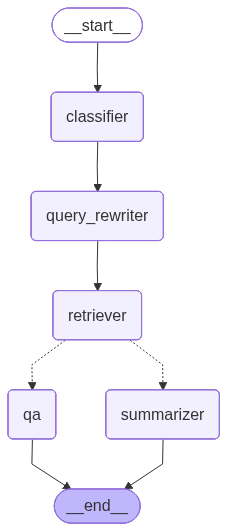

In [21]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(AgentState)
workflow.add_node("classifier", classifier_node)
workflow.add_node("query_rewriter", rewrite_query_node) 
workflow.add_node("retriever", retriever_node)
workflow.add_node("qa", qa_node)
workflow.add_node("summarizer", summarization_node)

workflow.set_entry_point("classifier")
workflow.add_edge("classifier", "query_rewriter")
workflow.add_edge("query_rewriter", "retriever") 

def route_after_retrieval(state: AgentState):
    if state["intent"] == "summarize":
        return "summarizer"
    return "qa"

workflow.add_conditional_edges(
    "retriever",
    route_after_retrieval,
    {
        "summarizer": "summarizer",
        "qa": "qa"
    }
)

workflow.add_edge("summarizer", END)
workflow.add_edge("qa", END)

app = workflow.compile()
app

In [22]:
result_qa = app.invoke({"query": "Сделай суммаризацию про p-adic arithmetic coding"})
display(Markdown(result_qa['final_answer']))

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

DEBUG: Модель ответила: 'YES

ДА, ЗАПРОС ТРЕБУЕТ СУММАР', Выбран интент: summarize


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

...

Adding requests:   0%|          | 0/7 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/7 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

# Аналитический обзор: ultrametric and generalized ultrametric in computational logic and in data analysis
 Ссылка на PDF: https://export.arxiv.org/pdf/1008.3585.pdf

**Аналитический обзор: применение диссимиляций и ультраметрических пространств в построении иерархий**

**Цель исследования**  
Работа посвящена разработке вычислительно эффективных и структурно симметричных методов построения иерархий на основе парных диссимиляций и ультраметрических пространств. Основная задача — формализовать иерархическую структуру как инвариантную к перестановкам подузлов, обеспечивая при этом возможность моделирования семантики аномалий, новизны и логических неоднозначностей в данных.

**Методология**  
Диссимиляция $ d : X \times X \to \mathbb{R}^+ $ определяется как симметричное, неотрицательное отображение, удовлетворяющее условиям $ d(x, y) = 0 $ при $ x = y $, $ d(x, y) \geq 0 $, и при наличии треугольной неравенства — расстоянием. При агломерации наблюдений из парных диссимиляций строится иерархия $ H $ — бинарное, корневое дерево, где каждый узел $ q \in H $ соответствует кластеру, и выполняется включение $ q \subset q' \Rightarrow \nu(q) < \nu(q') $. Ультраметрика $ D(q, q') = \nu(q') $ индуцируется через критерий минимума, что обеспечивает выполнение сильного треугольного неравенства: $ D(x, z) \leq \max(D(x, y), D(y, z)) $. В случае обобщённой ультраметрики $ d : I \times I \to \Gamma $, где $ \Gamma $ — частично упорядоченное множество, допускается многозначность, что позволяет моделировать немонотонные логические операторы.

**Результаты**  
Иерархия строится через агломерацию с использованием алгоритмов взаимных ближайших соседей, обеспечивающих время $ O(n^2) $ и уникальность кластеров. Вводится группа вращающегося (wreath) продукта $ G = P_{n-1} \wr \cdots \wr P_1 $, описывающая симметрии перестановок подузлов, что обеспечивает инвариантность структуры. Для аппроксимации объектов вводится оператор дилатации $ A $, соответствующий умножению на $ 1/p $, который порождает индуктивную последовательность $ \{q, Aq, A^2q, \dots\} $, формирующую сферически полное пространство. Применение дискретного Haar-преобразования к дендрограмме разлагает сигнал на внутренние (внутрикластерные) и межкластерные компоненты, позволяя представить каждый наблюдение $ x_i $ как цепочку приближений:  
$$
x_2 = s_7 + d_7
$$  
Аппроксимационная цепь определяется как последовательность вложенных кластеров, ведущая от полного набора к одиночному элементу. В контексте формального концепт-анализа диссимиляция интерпретируется как вектор совпадения по атрибутам, где $ d(c, f) = (1,1,0) $ соответствует подмножеству $ \{d_1, d_2\} $, а упорядочение по мощности обеспечивает иерархическую структуру.

**Заключение**  
Предложенная модель объединяет вычислительную эффективность, структурную симметрию и семантическую гибкость, позволяя применять ультраметрические и иерархические подходы к анализу данных, распознаванию лиц, анализу документов и логическим системам с отрицанием. Сферическая полнота пространства и Haar-преобразование обеспечивают сходимость и возможность аппроксимации, а обобщённая ультраметрика — адекватное моделирование неоднозначных логических процессов.

In [23]:
# visualize_summary(result_qa['final_answer'])

In [24]:
visualize_chunks(result_qa['debug_data'])

**Всего фрагментов:** `7` | **Общая длина:** `11855` симв.

---

### *Chunk 1*: introduction + pairwise dissimilarities + from dissimilarities to an ultrametric
>`Токенов: 600` | `Символов: 1480`


---


### *Chunk 2*: metric and ultrametric for geometry and topology of information + hierarchical agglomerative clustering
>`Токенов: 600` | `Символов: 1838`


---


...


---


### *Chunk 6*: approximation chain using a hierarchy + mapping of spherically complete space into dendrogram wavelet transform space + applications of generalized ultrametrics
>`Токенов: 600` | `Символов: 1864`


---


### *Chunk 7*: link with formal concept analysis + conclusion
>`Токенов: 600` | `Символов: 1704`


---


In [25]:
result_qa = app.invoke({"query": "Что такое dropout?"})
display(Markdown(result_qa['final_answer']))

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

DEBUG: Модель ответила: 'NO

ОБЪЯСНЕНИЕ: ПОЛЬЗОВАТЕЛЬ', Выбран интент: question


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

🔍 Оригинал: Что такое dropout?
🚀 Оптимизированный поиск: What is dropout in deep learning?


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Dropout — это техника регуляризации в обучении нейронных сетей, при которой во время обучения случайным образом отключаются (устанавливаются в ноль) некоторые нейроны (или их соединения) с заданной вероятностью. Это помогает предотвратить переобучение, так как заставляет каждый нейрон учиться полезным, независимым признакам, не полагаясь на другие нейроны для корректировки ошибок.

Ключевые особенности dropout:

- **Повышает обобщение**: заставляет нейроны учиться более универсальным и простым признакам (например, линейным "линиям" или "чертежам"), а не зависимым от других нейронов.
- **Снижает ко-адаптацию**: предотвращает ситуацию, когда нейроны становятся слишком зависимыми друг от друга.
- **Упрощает обучение**: позволяет модели лучше обобщать на новых данных, особенно в сложных сетях.
- **Простота реализации**: проще, чем байесовская модель, и требует меньше вычислительных ресурсов.
- **На тесте**: при оценке модели отключения не происходит — все нейроны активны, и предсказания получаются как среднее значение по множеству "отключённых" сетей.

В контексте текста:
- Dropout улучшает результаты по сравнению с обычной обратной передачей (backpropagation): например, на MNIST снизил ошибки с 118 до 92, а на Deep Boltzmann Machines — с 94 до 79.
- Важно, что dropout особенно эффективен в сложных моделях, включая CNN, и помогает избежать переобучения даже при использовании сложных архитектур.
- Вероятность отключения обычно устанавливается на уровне 0.5, хотя может быть адаптирована в зависимости от данных или валидации.

In [26]:
result_qa['relevant_docs']

,vector,id,article_id,title,text,_distance
0,"[0.008240003, -0.0558959, 0.029744785, 0.04938...",1207.0580_10,1207.0580,improving neural networks by preventing co-ada...,as before. The model was trained for 1000 epoc...,0.574871
1,"[-0.0652649, -0.034077857, 0.04785723, 0.03975...",1207.0580_6,1207.0580,improving neural networks by preventing co-ada...,layers works better than dropout in only one h...,0.700139
2,"[0.009530494, -0.007702438, 0.03527538, 0.0073...",1207.0580_13,1207.0580,improving neural networks by preventing co-ada...,"Markets, Legal/Judicial, Production/Services, ...",0.784691
3,"[-0.040178847, -0.049019914, 0.06393662, 0.003...",1207.0580_21,1207.0580,improving neural networks by preventing co-ada...,patches of the 256 × 256 input image: the cent...,0.798288
4,"[-0.0659989, -0.02960897, -0.037415996, 0.0296...",1207.0580_8,1207.0580,improving neural networks by preventing co-ada...,of co-adapted genes. It also reduces the proba...,0.824418


In [27]:


result_sum = app.invoke({"query": "Найди статью по computer vision"})
display(Markdown(result_sum['final_answer']))

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

DEBUG: Модель ответила: 'YES

ОБЪЯСНИ СВОЙ ОТВЕТ. З', Выбран интент: summarize


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

🔍 Оригинал: Найди статью по computer vision
🚀 Оптимизированный поиск: Find a research article on computer vision


Для статьи 'notes on a new philosophy of empirical science' нет доступных разделов.

In [28]:
result_qa = app.invoke({"query": "in a quantum mechanical model, diosi, feldmann and kosloff arrived at a conjecture stating that the"})
display(Markdown(result_qa['final_answer']))

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

DEBUG: Модель ответила: 'YES

ОБЪЯСНИ СВОЙ ВЫБОР.

З', Выбран интент: summarize


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

...

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

# Аналитический обзор: the need for structure in quantum speedups
 Ссылка на PDF: https://export.arxiv.org/pdf/0911.0996.pdf

**Цель исследования**  
Цель работы — доказать полиномиальную связь между случайной и квантовой сложностью запросов для всех симметричных функций, в частности, для перестановочно-инвариантных. В центре внимания — конъектура Ватроуса, утверждающая, что для любой симметричной функции \( f \) случайная сложность \( R(f) \) и квантовая сложность \( Q(f) \) связаны полиномиально, то есть \( R(f) = \text{poly}(Q(f)) \). Особое внимание уделяется перестановочно-инвариантным функциям, где значение функции зависит только от веса входа, а не от его структуры.

**Методология**  
Для достижения цели разработаны и анализируются следующие подходы. Во-первых, предложен простой классический алгоритм, который оценивает мультипликативность каждого элемента входа через выборку, что позволяет эффективно моделировать поведение функции. Введено понятие *жёсткого ядра* — двух типов входов \( A^* \) и \( B^* \), таких, что сложность их различения определяет основную полиномиальную часть общей сложности функции. Ключевым инструментом является *гибридный аргумент* (chopping procedure): строится последовательность входов \( A_0, A_1, \ldots, A_{2L} \), где \( A_0 = A^* \), \( A_{2L} = B^* \), и каждый шаг \( A_\ell \to A_{\ell+1} \) постепенно приближает тип входа к следующему, уменьшая разницу между ними. Для каждого перехода \( A_\ell \to A_{\ell-1} \) доказываются нижние границы квантовой сложности различения двумя способами:  
1) с помощью обобщённой теоремы Амбайниса (quantum adversary method), применимой при небольшом количестве изменений элементов;  
2) через редукцию к задаче \( \text{SetEquality} \), в частности к \( 3\text{SetEquality} \), для которой известна нижняя граница \( Q(3\text{SetEquality}) = \Omega(N^{1/3}) \) (доказанная Зандри).  
Дополнительно используется теорема о влиянии (influence): для любого ограниченного полинома степени \( d \) существует переменная с высоким влиянием, что позволяет симулировать квантовый алгоритм классическим путём, используя структуру полиномиальности.

**Результаты**  
Для симметричных функций доказана оценка \( R(f) = O(Q(f)^7 \cdot \text{polylog} Q(f)) \), что подтверждает полиномиальную связь. Авторы конъюгируют, что более точная оценка — \( R(f) = O(Q(f)^2) \). Для перестановочно-инвариантных функций, определённых на множествах с фиксированным весом, доказано, что \( R(f) = O(Q(f)^2) \) даже для частичных функций. Нижняя граница для сложности различения \( A_\ell \) и \( A_{\ell-1} \) подтверждает, что полиномиальная связь не является тривиальной и требует глубокого анализа структуры входов.

**Заключение**  
Работа подтверждает конъектуру Ватроуса для важного класса функций — перестановочно-инвариантных. Полученные результаты демонстрируют, что квантовая сложность не превосходит случайной на полиномиальный множитель, что имеет фундаментальное значение для теории сложности и квантовой вычислительной теории.

In [29]:
result_qa = app.invoke({"query": "Какие алгоритмы используются в cs?"})
display(Markdown(result_qa['final_answer']))

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

DEBUG: Модель ответила: 'YES

ОБЪЯСНИ СВОЙ ВЫБОР. З', Выбран интент: summarize


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

...

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

# Аналитический обзор: sign language tutoring tool
 Ссылка на PDF: https://export.arxiv.org/pdf/0802.2428.pdf

**Цель исследования**  
Цель проекта — разработка системы *Tutoring Demonstrator*, предназначенной для практики знаковой речи с предоставлением визуальной обратной связи. Система позволяет пользователям воспроизводить демонстрируемые жесты на основе видео, а также получать оценку выполнения в виде синтезированной, карикатурной версии жеста. Особое внимание уделяется интрамодальной природе знаковой речи, при которой полная семантическая информация содержится не только в жестах рук, но и в выражениях лица, движениях головы и плеч. В рамках проекта разрабатывается интегрированная система распознавания, объединяющая данные о жестах рук и движениях головы, что позволяет повысить точность и полноту интерпретации знаков.

**Методология**  
Для распознавания жестов рук используется модель скрытых марковских процессов (HMM), включающая методы онлайн-обнаружения, распознавания непрерывных знаков и моделирования фонем. Обнаружение рук осуществляется с помощью разноцветных перчаток, а классификация — на основе гистограмм в цветовом пространстве HSV с двойным порогом и итеративной оптимизацией ошибок. Для устранения шумов в траекториях применяются фильтры Калмана с моделью постоянной скорости, где предсказание позиции корректируется по результатам сегментации. Из бинарных изображений вычисляются 19 признаков формы рук: параметры эллипса (угол α, sin(2α), cos(2α)), периметр, площадь, размеры bounding box. Признаки нормализуются в диапазоне [0,1], при этом сохраняются неснижаемые значения для 5 признаков, связанных с глубиной. Классификация форм рук реализована с использованием алгоритма K-средних (K-means), обеспечивающего группировку образцов по схожести признакового вектора.

**Результаты**  
База данных включает 19 знаков американского жестового языка (ASL), отобранных с учётом значимости движений головы. Каждый знак был записан пять раз с восьмью испытуемыми при разрешении 640×480 пикселей и частоте кадров 25 кадров/с. Система обеспечивает эффективное обнаружение и классификацию жестов, а также интегрирует данные о движении головы, что повышает обобщающую способность модели. Визуальная обратная связь формируется на основе синтезированной карикатурной версии жеста, что позволяет пользователю визуально оценить отклонения от эталона.

**Заключение**  
Разработанная система *Tutoring Demonstrator* представляет собой эффективный инструмент для обучения знаковой речи, сочетающий точное распознавание жестов с интеграцией мультимодальных данных. Использование HMM, фильтров Калмана и признакового описания формы рук обеспечивает высокую устойчивость к шуму и хорошую классификацию. Результаты демонстрируют потенциал системы как образовательного инструмента, способного поддерживать пользователей в процессе освоения сложной, интрамодальной системы коммуникации.

In [30]:
result_qa

{'query': 'Какие алгоритмы используются в cs?',
 'search_query': 'What machine learning and deep learning algorithms are commonly used in computer science and computer vision?',
 'intent': 'summarize',
 'relevant_docs':                                               vector            id article_id  \
 0  [-0.08454326, -0.029164134, -0.062304024, -0.1...  0802.2428_19  0802.2428   
 1  [0.008875437, -0.0757757, 0.053176645, -0.0071...   1208.0959_0  1208.0959   
 2  [-0.08000192, -0.069362506, 0.024416966, -0.03...   1202.2745_1  1202.2745   
 3  [-0.07730006, 0.022866407, -0.0101672085, -0.0...   1208.1315_0  1208.1315   
 4  [-0.034122374, -0.050894722, -0.038715582, -0....   1009.0623_5  1009.0623   
 
                                                title  \
 0                        sign language tutoring tool   
 1               recklessly approximate sparse coding   
 2  multi-column deep neural networks for image cl...   
 3        data selection for semi-supervised learning   
 4

In [31]:
# class AgentState(TypedDict):
#     query: str
#     intent: str  # 'summarize' или 'rag'
#     relevant_articles: List[dict]  # Список найденных статей/чанков
#     summary: str
#     final_answer: str
    
# def summarization_node(state: AgentState):
#     """Узел графа для суммаризации."""
#     # Предполагаем, что в state['relevant_articles'] лежат словари секций
#     # создаем перекрытия для первой статьи
#     article = state['relevant_articles'][0]
    
#     # Превращаем список чанков (или словарь) в структуру с перекрытиями
#     # Если article['chunks'] это словарь {title: text}:
#     overlap_data = create_overlap_dict(article['sections_dict'], overlap_len=250)
    
#     # Запускаем наш новый пайплайн
#     report = run_summarization_pipeline(overlap_data)
    
#     return {"final_answer": report}

In [32]:


# def process_chunks(pre_parsed_chunks, max_chunk_tokens=3000):
#     """
#     Проверяет готовые чанки. Если чанк слишком большой, дробит его.
#     """
#     splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
#         tokenizer=tokenizer,
#         chunk_size=max_chunk_tokens,
#         chunk_overlap=200
#     )
    
#     final_chunks = []
#     for chunk in pre_parsed_chunks:
#         token_count = len(tokenizer.encode(chunk))
#         if token_count <= max_chunk_tokens:
#             final_chunks.append(chunk)
#         else:
#             sub_chunks = splitter.split_text(chunk)
#             final_chunks.extend(sub_chunks)
            
#     return final_chunks

# def prepare_prompt(text, system_prompt):
#     messages = [{"role": "user", "content": f"{system_prompt}:\n\n{text}"}]
#     return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

# def run_summarization_pipeline(pre_parsed_chunks, p0, p1):
#     # ready_chunks = process_chunks(pre_parsed_chunks, max_chunk_tokens=3500)

#     map_prompts = [prepare_prompt(c, p0) for c in ready_chunks]
#     chunk_summaries = gen_chunks_runnable.invoke(map_prompts)
    
#     combined_text = "\n".join(chunk_summaries)
    
#     reduce_prompt = prepare_prompt(combined_text, p1)
#     final_summaries = gen_final_runnable.invoke([reduce_prompt])
#     return final_summaries[0]

# summaries_list = []
# gen_chunks_runnable = RunnableLambda(lambda x: vllm_gen(x, max_new_tokens=512))
# gen_final_runnable = RunnableLambda(lambda x: vllm_gen(x, max_new_tokens=1280))
# prompt_0 = """Act as a professional Science Editor. 
# Your task is to extract key information from this fragment of a scientific paper.
# 1. Identify specific objectives, technical methodologies, and key data mentioned.
# 2. Maintain technical terminology and the original language.
# 3. Be objective: do not add interpretations or info not present in the text.
# 4. Output format: Use a dense bulleted list of the most important points.
# 5. Avoid any introductory or concluding remarks—just the facts."""
# prompt_1 = """Act as a Senior Science Editor. 
# Task: Synthesize a single, coherent executive summary based on the provided fragment summaries.

# Structure your response strictly as follows:
# - **Goal**: Clear statement of the research objective and problem.
# - **Methods**: Summary of the technical approach, experiments, or theoretical framework.
# - **Results**: Detailed overview of key findings and performance improvements.
# - **Conclusion**: The overall significance and final takeaway.

# Requirements:
# - Style: Academic, professional, and precise.
# - Formulas: Do not use any mathematical formulas or LaTeX. Describe results in words.
# - Length: Aim for 500-650 words. Ensure information density is high.
# - Integrity: Ensure the text ends with a complete, definitive concluding sentence.
# - Do not add any text outside of the headers. Final summary only."""

